In [1]:
import os 
import zipfile
import numpy as np
from PIL import Image
from pathlib import Path
import h5py as h5
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

In [6]:
root = Path("/Volumes/warm_SD/data/285/00_series/00/results")
files = [f for f in os.listdir(root) if f.endswith('.h5')]

print(files)

['Panorama_285_02_50x.h5', 'Panorama_285_03_50x.h5', 'Panorama_285_01_50x.h5']


In [7]:

for file in files:
    filename = file.split('.')[0]

    with h5.File(root / file,"r") as h5F:
        # image = h5F["image"][:]
        labels = h5F["labels"][:]
        labels_bin = (labels > 0).astype(np.uint8)

        # Image.fromarray(image).save(root / f"{filename}.tiff")
        # Image.fromarray(labels).save(root / f"{filename}.labels.tiff")
        Image.fromarray(labels_bin).save(root / f"{filename}.labels_bin.tiff")
    

(2234, 23050) int16


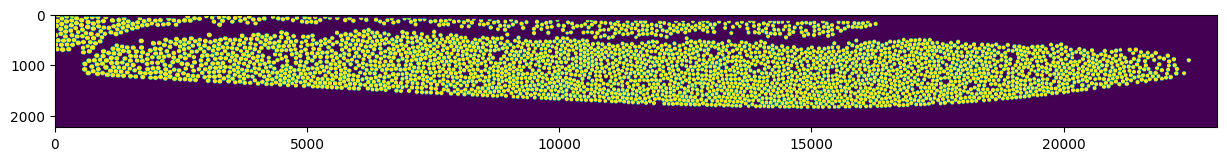

In [ ]:
img = Image.open(root / "160_00_01_50x.labels_.tiff")
labels = np.array(img, dtype=np.int16)
print(labels.shape, labels.dtype)

plt.figure(figsize=(15,8))
plt.imshow(labels)

In [27]:
mask = Image.open("/Volumes/warm_SD/data/160/00_series/00/160_00_01_50x.mask.tif")

3401
int16


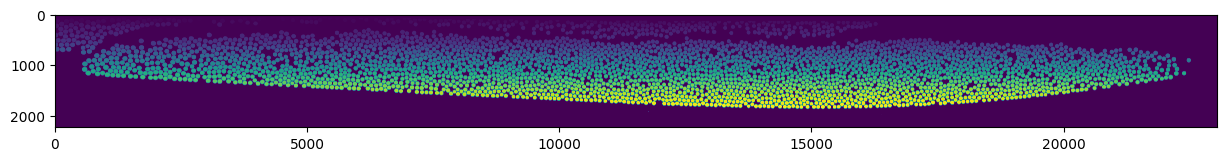

In [32]:
instances =label(labels).astype(np.int16)
instances_no = np.unique(instances)
print(len(instances_no))
print(instances.dtype)
plt.figure(figsize=(15,8))
plt.imshow(instances)

In [33]:
Image.fromarray(instances).save("/Volumes/warm_SD/data/160/00_series/00/results/160_00_01_50x.instances.tif")

2994
int64


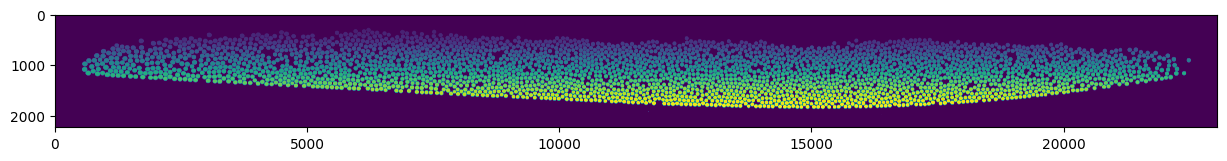

In [30]:
instances_masked = instances * mask
instances_no = np.unique(instances_masked)
print(len(instances_no))
print(instances.dtype)
plt.figure(figsize=(15,8))
plt.imshow(instances_masked)